Downsampling the UiS4ADL dataset from 100hz to 32hz to match the sampling frequency of the PAAL ADL dataset.

In [ ]:
import os
import warnings
import json

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import welch
import matplotlib.pyplot as plt

# Suppress warnings from Python and external libraries
os.environ["PYTHONWARNINGS"] = "ignore"  # Suppress Python warnings
warnings.filterwarnings("ignore")

In [ ]:
with open('../Data/adl_dict.json', 'r') as f:
    adl_dict = json.load(f)

In [ ]:
initial_fs = 100 # sampling frequency in Hz
path = r"../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv"

target_fs = 32 # target sampling frequency in Hz

In [ ]:
df = pd.read_csv(path)

In [ ]:
metadata_cols = ['adl', 'session', 'subject', 'fileID']
sensor_cols = ['accX[mg]', 'accY[mg]', 'accZ[mg]', 'gyroX[mdps]',
       'gyroY[mdps]', 'gyroZ[mdps]', 'magnX[mG]', 'magnY[mG]', 'magnZ[mG]',
       'fxQ1', 'fxQ2', 'fxQ3', 'fxQ4', 'fxYaw[deg]', 'fxPitch[deg]',
       'fxRoll[deg]', 'fxGravityX[g]', 'fxGravityY[g]', 'fxGravityZ[g]',
       'fxLinAccX[g]', 'fxLinAccY[g]', 'fxLinAccZ[g]', 'fxHeading[deg]']

## Downsample the UiS4ADL dataset

Linear interpolation was used as a resampling method.

In [ ]:
def resample_file(df_file, target_hz=32):
    t_orig = df_file['timestamp'].values / 1000.0 # timestamp in seconds
    
    duration = t_orig[-1]
    t_new = np.arange(0, duration, 1 / target_hz)

    out = {'timestamp': t_new * 1000.0}  # timestamp in milliseconds

    # Resample sensor data using interpolation
    for col in sensor_cols:
        f = interp1d(t_orig, df_file[col].values, kind='linear')
        out[col] = f(t_new)

    df_out = pd.DataFrame(out)

    # Attach metadata
    for col in metadata_cols:
        df_out[col] = df_file[col].iloc[0]

    return df_out

In [ ]:
df_32hz = (
    df.groupby('fileID')
      .apply(resample_file)
      .reset_index(drop=True)
)

In [ ]:
df_32hz

,timestamp,accX[mg],accY[mg],accZ[mg],gyroX[mdps],gyroY[mdps],gyroZ[mdps],magnX[mG],magnY[mG],magnZ[mG],...,fxGravityY[g],fxGravityZ[g],fxLinAccX[g],fxLinAccY[g],fxLinAccZ[g],fxHeading[deg],adl,session,subject,fileID
0,0.00,-198.000,-348.000,878.000,-58730.00,-26390.00,73850.00,-112.000,208.000,-522.000,...,-0.264000,-0.819000,0.162000,-0.066000,0.059000,32.628000,1,1,0,70
1,31.25,-219.125,-375.500,785.500,-87430.00,-39042.50,66290.00,-126.375,219.125,-514.500,...,-0.293000,-0.795375,0.154500,-0.073875,-0.009875,28.996250,1,1,0,70
2,62.50,-193.750,-450.250,767.750,-67375.00,-49542.50,56717.50,-122.500,237.750,-507.000,...,-0.294000,-0.780750,0.100750,-0.100250,-0.013000,25.853000,1,1,0,70
3,93.75,-150.625,-539.500,785.875,-42008.75,-55623.75,44117.50,-119.500,257.500,-499.875,...,-0.298875,-0.769625,0.024625,-0.148250,0.016250,23.132375,1,1,0,70
4,125.00,-133.500,-522.000,795.000,-910.00,-55020.00,33110.00,-119.000,262.000,-495.000,...,-0.296000,-0.769000,0.044000,-0.162500,0.026000,21.762000,1,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2696620,23343.75,933.750,-329.000,-649.000,113347.50,-17290.00,-68223.75,-125.375,-301.375,132.250,...,0.927000,0.368750,-0.262750,-0.006750,-0.280250,249.551625,9,5,3245,4947
2696621,23375.00,1161.000,-326.000,-262.000,163870.00,-37240.00,-54460.00,-135.000,-282.500,149.000,...,0.921000,0.384000,-0.263000,-0.240000,0.122000,243.920000,9,5,3245,4947
2696622,23406.25,1234.375,4.125,-341.875,189700.00,-16966.25,-55685.00,-138.625,-257.875,157.875,...,0.916000,0.394000,0.075625,-0.318375,0.052125,237.614125,9,5,3245,4947
2696623,23437.50,1121.750,139.500,-360.500,135117.50,-7647.50,-46882.50,-141.250,-248.500,168.750,...,0.915250,0.395250,0.217000,-0.206500,0.034750,232.121500,9,5,3245,4947


## Drop columns

Since PAAL ADL has only 3 acceleration channels, the gyroscope and the remaining channels will be removed from the UiS4ADL dataset for consistency.

In [ ]:
df_32hz_acc = df_32hz.drop(columns=[c for c in df_32hz.columns if c not in ['timestamp', 'accX[mg]', 'accY[mg]', 'accZ[mg]', 'adl', 'session', 'subject', 'fileID']])
df_32hz_acc

,timestamp,accX[mg],accY[mg],accZ[mg],adl,session,subject,fileID
0,0.00,-198.000,-348.000,878.000,1,1,0,70
1,31.25,-219.125,-375.500,785.500,1,1,0,70
2,62.50,-193.750,-450.250,767.750,1,1,0,70
3,93.75,-150.625,-539.500,785.875,1,1,0,70
4,125.00,-133.500,-522.000,795.000,1,1,0,70
...,...,...,...,...,...,...,...,...
2696620,23343.75,933.750,-329.000,-649.000,9,5,3245,4947
2696621,23375.00,1161.000,-326.000,-262.000,9,5,3245,4947
2696622,23406.25,1234.375,4.125,-341.875,9,5,3245,4947
2696623,23437.50,1121.750,139.500,-360.500,9,5,3245,4947


### Sanity checks

In [ ]:
# Check whether the sampling grid is regular after resampling
expected = 1000.0 / float(target_fs)  # in miliseconds
tol_ms=1e-12
irregular_timestamps_files = []
for fid, g in df_32hz_acc.groupby('fileID'):
    ts = g['timestamp'].values
    dt = np.diff(ts)
    max_err = np.max(np.abs(dt - expected))
    if max_err > tol_ms:
        irregular_timestamps_files.append((fid, max_err, np.unique(dt)))
if not irregular_timestamps_files:
    print(f"All files have a regular sampling grid (expected {expected:.3f} ms, tol {tol_ms} ms).")
else:
    print(f"Files with irregular timestamps were detected (expected {expected:.3f} ms, tol {tol_ms} ms):")
    for fid, max_err, uniques in irregular_timestamps_files:
        print(f"fileID {fid}: max err = {max_err:.6f} ms, unique dt ≈ {uniques}")

All files have a regular sampling grid (expected 31.250 ms, tol 1e-12 ms).


In [ ]:
# Check metadata integrity, 'adl', 'session' and 'subject' should not vary within a file
errors = []
for col in metadata_cols:
    if col == 'fileID':
        continue
    max_unique = df_32hz_acc.groupby('fileID')[col].nunique().max()
    if max_unique != 1:
        errors.append((col, max_unique))

if errors:
    for col, max_u in errors:
        print(f"Error: '{col}' varies within a file (max unique per fileID = {max_u})")
else:
    print("All files have consistent labels.")

All files have consistent labels.


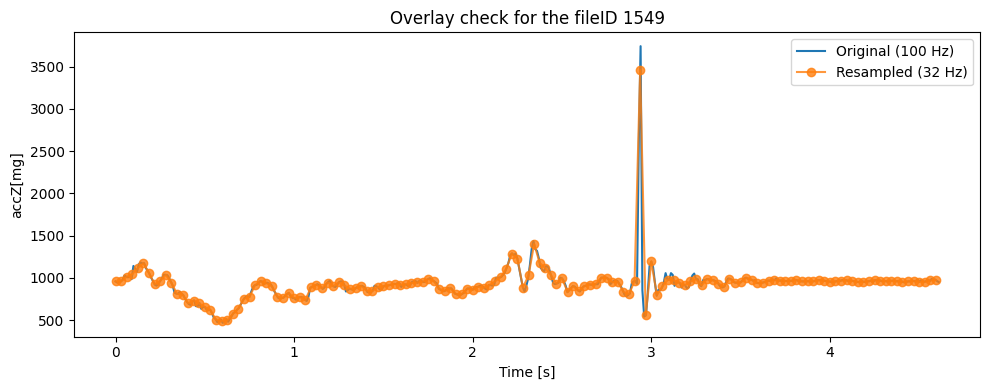

In [ ]:
# Time-domain overlay plots of original vs resampled to visually confirm that resampling preserves the shape/amplitude
file_id = 1549
col = 'accZ[mg]'  # or whatever your signal column is called
t_max = 10.0  # seconds
dfo = df[df.fileID == file_id]
dfr = df_32hz_acc[df_32hz_acc.fileID == file_id]
to = dfo['timestamp'].values / 1000.0
tr = dfr['timestamp'].values / 1000.0
mask_o = to <= t_max
mask_r = tr <= t_max
plt.figure(figsize=(10, 4))
plt.plot(to[mask_o], dfo[col].values[mask_o], label='Original (100 Hz)')
plt.plot(tr[mask_r], dfr[col].values[mask_r], 'o-', label='Resampled (32 Hz)', alpha=0.8)
plt.xlabel('Time [s]')
plt.ylabel(col)
plt.legend()
plt.title(f'Overlay check for the fileID {file_id}')
plt.tight_layout()
plt.show()

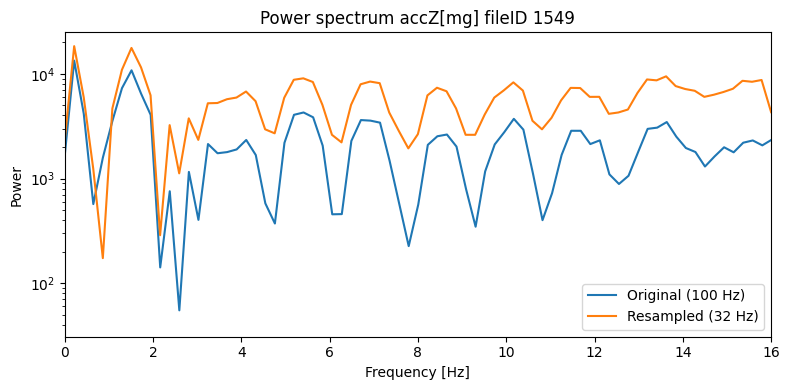

In [ ]:
# Power spectral density comparison of original vs resampled (up to 16 Hz) to ensure that resampling does not introduce artifacts or lose important frequencies
file_id = 1549
col = 'accZ[mg]'
dfo = df[df.fileID == file_id]
dfr = df_32hz_acc[df_32hz_acc.fileID == file_id]
xo = dfo[col].values
xr = dfr[col].values
fo, po = welch(xo, fs=initial_fs, nperseg=2048)
fr, pr = welch(xr, fs=target_fs, nperseg=512)
plt.figure(figsize=(8, 4))
plt.semilogy(fo, po, label='Original (100 Hz)')
plt.semilogy(fr, pr, label='Resampled (32 Hz)')
plt.xlim(0, 16)   # Nyquist frequency (half of the sampling rate)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.legend()
plt.title(f'Power spectrum {col} fileID {file_id}')
plt.tight_layout()
plt.show()

## Save the downsampled dataset

In [ ]:
 # Save the combined DataFrame to a new CSV file
output_file_32_acc = f"../Data/UiS4ADL/Processed/UiS4ADL_acc_{target_fs}hz.csv" # acceleraometer-only version
output_file_32 = f"../Data/UiS4ADL/Processed/UiS4ADL_{target_fs}hz.csv"

# Remove the file if it already exists
if os.path.exists(output_file_32_acc):
    os.remove(output_file_32_acc)
    print(f"{output_file_32_acc} has been removed successfully.")
else:
    print(f"{output_file_32_acc} does not exist.")
    
# Remove the file if it already exists
if os.path.exists(output_file_32):
    os.remove(output_file_32)
    print(f"{output_file_32} has been removed successfully.")
else:
    print(f"{output_file_32} does not exist.")


# Save the combined DataFrame to a CSV file
df_32hz_acc.to_csv(output_file_32_acc, index=False)
print(f"The dataset with accelerometer data was saved to {output_file_32_acc}")

df_32hz.to_csv(output_file_32, index=False)
print(f"The full version of the dataset was saved to {output_file_32}")

../Data/UiS4ADL/Processed/UiS4ADL_acc_32hz.csv does not exist.
../Data/UiS4ADL/Processed/UiS4ADL_32hz.csv does not exist.
The dataset with accelerometer data was saved to ../Data/UiS4ADL/Processed/UiS4ADL_acc_32hz.csv
The full version of the dataset was saved to ../Data/UiS4ADL/Processed/UiS4ADL_32hz.csv
